# Codificación One-Hot frente a codificación de etiquetas

Este ejercicio está contextualizado en Chile para mostrar cómo transformar variables categóricas a variables numéricas antes de entrenar modelos de machine learning.

Usaremos ejemplos simples con países de la región y niveles de alerta, manteniendo el enfoque en la interpretación de cada técnica.

In [4]:
# Codificacion One-Hot usando pandas con foco en Chile

import pandas as pd

paises = ['Chile', 'Peru', 'Argentina', 'Chile', 'Bolivia', 'Chile']
df = pd.DataFrame({'Pais': paises})

one_hot = pd.get_dummies(df['Pais'], dtype=int)
print(one_hot)

   Argentina  Bolivia  Chile  Peru
0          0        0      1     0
1          0        0      0     1
2          1        0      0     0
3          0        0      1     0
4          0        1      0     0
5          0        0      1     0


# Comprension de la codificacion de etiquetas

La codificacion de etiquetas asigna un numero entero unico a cada categoria.

En este ejemplo, simulamos niveles de alerta en Chile para mostrar como una variable categorica puede convertirse en una sola columna numerica.

In [5]:
from sklearn.preprocessing import LabelEncoder

nivel_alerta = ['Baja', 'Media', 'Alta', 'Media', 'Baja']
df = pd.DataFrame({'Nivel_alerta': nivel_alerta})

codificador = LabelEncoder()
df['Nivel_alerta_codificado'] = codificador.fit_transform(df['Nivel_alerta'])
print(df)

  Nivel_alerta  Nivel_alerta_codificado
0         Baja                        1
1        Media                        2
2         Alta                        0
3        Media                        2
4         Baja                        1


# Comparativo profesional: One-Hot vs Codificación de Etiquetas (Chile)

## Resumen ejecutivo

| Técnica | Fortalezas clave | Riesgo principal | Recomendación rápida |
|---|---|---|---|
| **One-Hot** | Máxima interpretabilidad para variables nominales. | Aumenta mucho el número de columnas. | Usar en variables como `país`, `comuna` o `región` con baja/media cardinalidad. |
| **Codificación de Etiquetas** | Muy eficiente en memoria y más simple de implementar. | Puede introducir orden artificial en variables sin jerarquía. | Usar en variables ordinales o con modelos de árboles. |

## Matriz visual de decisión

| Criterio | One-Hot | Codificación de Etiquetas |
|---|---:|---:|
| Interpretabilidad para variables nominales | Alta | Media |
| Escalabilidad con muchas categorías | Baja | Alta |
| Consumo de memoria | Alto | Bajo |
| Compatibilidad con modelos lineales | Alta | Media |
| Compatibilidad con árboles de decisión | Media | Alta |

## Guía práctica (contexto Chile)

- Si la variable es **nominal** (ej.: país de origen: Chile, Perú, Argentina), prioriza **One-Hot**.
- Si la variable es **ordinal** (ej.: nivel de alerta: baja, media, alta), prioriza **Codificación de Etiquetas**.
- Si tienes **miles de categorías** (por ejemplo, códigos territoriales muy granulares), evita One-Hot puro y evalúa reducción de cardinalidad antes de codificar.

## Conclusión

Para proyectos con datos categóricos en Chile, una estrategia robusta es:
1. One-Hot para variables nominales críticas.
2. Codificación de Etiquetas para variables ordinales o escenarios con restricción de memoria.
3. Validar el impacto final en métricas del modelo antes de cerrar la técnica.

# Características principales:
- Variables Nominales:
    - Orden: No tienen orden ni jerarquía.
    - Propósito: Etiquetar o clasificar en grupos distintos.
    - Operaciones: Solo se puede calcular la moda y frecuencias.
    - Ejemplos: Estado civil, nacionalidad, color de ojos, tipo de sangre.
- Variables Ordinales:
    - Orden: Siguen un orden, rango o jerarquía significativa.
    - Propósito: Clasificar y ordenar elementos.
    - Operaciones: Se pueden calcular la moda, mediana y percentiles, pero no medias aritméticas.
    - Distancia: La diferencia entre categorías no es uniforme o cuantificable.
    - Ejemplos: Nivel socioeconómico, escalas de satisfacción (bajo, medio, alto), clasificaciones de carreras

## Ejemplo para clase: ColumnTransformer + Pipeline (scikit-learn)

En este ejemplo combinamos en un solo flujo de trabajo:
- Preprocesamiento de variables numéricas (`StandardScaler`).
- Codificación One-Hot para variables nominales (`OneHotEncoder`).
- Codificación ordinal para una variable con jerarquía (`OrdinalEncoder`).
- Entrenamiento de un modelo de clasificación (`LogisticRegression`).

Objetivo didáctico: mostrar cómo evitar fugas de datos y dejar el preprocesamiento integrado con el modelo en un único pipeline reproducible.

> El contexto del ejemplo es didáctico y está ambientado en Chile.

Se simula un caso de clasificación donde se quiere predecir si una persona compra un seguro (compra_seguro) usando:

- Variables numéricas: edad e ingreso mensual.
- Variable categórica nominal: región.
- Variable categórica ordinal: nivel de alerta (baja, media, alta).

> La idea pedagógica es mostrar en clases cómo combinar correctamente:

- Escalado para numéricas.
- One-Hot para nominales.
- Codificación ordinal para variables con jerarquía.

> Todo dentro de un Pipeline con ColumnTransformer para evitar fugas de datos y dejar un flujo reproducible de entrenamiento y predicción.

## ¿Por qué usar regresión logística en este ejemplo?

La **regresión logística** es un modelo de clasificación supervisada que se utiliza cuando la variable objetivo tiene dos posibles valores. En este caso, queremos predecir si una persona **compra un seguro** (`1`) o **no lo compra** (`0`).

### ¿Por qué es adecuada para estos datos?

- La variable objetivo `compra_seguro` es **binaria**, por lo que la regresión logística es una opción natural.
- El modelo puede trabajar correctamente después del preprocesamiento realizado con `ColumnTransformer`:

  - Las variables numéricas (`edad`, `ingreso_mensual`) se escalan con `StandardScaler`.
  - La variable nominal (`region`) se transforma con `OneHotEncoder`.
  - La variable ordinal (`nivel_alerta`) se convierte a números conservando su jerarquía con `OrdinalEncoder`.

### ¿Qué aprende el modelo?

La regresión logística aprende una relación entre las variables de entrada y la **probabilidad** de que ocurra el evento de interés. En este caso, estima la probabilidad de que una persona compre un seguro.

Matemáticamente, el modelo calcula una combinación lineal de las variables y luego aplica una función logística para transformar ese valor en una probabilidad entre `0` y `1`.

### ¿Cómo se interpreta la salida?

- Si la probabilidad estimada es cercana a `1`, el modelo considera más probable que la persona **sí compre** el seguro.
- Si la probabilidad estimada es cercana a `0`, el modelo considera más probable que **no compre** el seguro.
- Luego, el modelo convierte esa probabilidad en una clase final (`0` o `1`).

### Ventajas didácticas en este ejercicio

- Es un modelo **fácil de explicar** en clases.
- Permite conectar el preprocesamiento con una predicción probabilística.
- Ayuda a mostrar la diferencia entre **predecir una clase** y **estimar una probabilidad**.
- Es una buena base para comparar más adelante con árboles de decisión o random forest.

### Idea clave para la clase

En este ejemplo, la regresión logística no solo clasifica, sino que también responde a una pregunta muy útil en negocios:

**¿Con qué probabilidad esta persona compraría un seguro según su edad, ingreso, región y nivel de alerta?**

## ¿Qué es predecir una clase vs estimar una probabilidad? (Lenguaje común)

### Predecir una clase
Es la **decisión final** del modelo: **Sí** o **No** (en números: `1` o `0`).

**Analogía:** Es como cuando tu mamá te pregunta "¿Vas a ir a la fiesta?" y respondes "**Sí**" o "**No**". Es una respuesta clara y definitiva.

En nuestro ejemplo: **¿Esta persona compra un seguro?** → Respuesta: **Sí (1)** o **No (0)**

### Estimar una probabilidad
Es qué tan **seguro** está el modelo de su respuesta, expresado como un **porcentaje** (o número entre 0 y 1).

**Analogía:** Es como decir "Estoy **80% seguro** de que vas a ir a la fiesta" o "Tengo solo **20% de confianza** en que irás". Es una medida de *confianza*, no una respuesta definitiva.

En nuestro ejemplo: **¿Qué tan probable es que esta persona compre un seguro?** → Respuesta: **0.82** (82% de probabilidad) o **0.31** (31% de probabilidad)

### ¿Cómo se relacionan?

El modelo primero **estima la probabilidad**, y luego **convierte esa probabilidad en una clase** usando una regla simple:

- Si la probabilidad ≥ 0.5 → Predice clase **1** (Sí, compra seguro)
- Si la probabilidad < 0.5 → Predice clase **0** (No, no compra seguro)

### Ejemplo práctico

Para un nuevo cliente:
- Probabilidad estimada: **0.82** → Esto significa: "Tengo 82% de confianza"
- Clase predicha: **1** → Esto significa: "Entonces predigo: Sí, compra seguro"

Para otro cliente:
- Probabilidad estimada: **0.31** → Esto significa: "Tengo solo 31% de confianza"
- Clase predicha: **0** → Esto significa: "Entonces predigo: No, no compra seguro"

### ¿Cuál es más útil en negocios?

**Ambas**, porque:
- La **clase predicha** te da una respuesta clara para una decisión rápida.
- La **probabilidad** te dice qué tan seguro está el modelo, lo que es muy importante para decisiones de negocio (ej: si la probabilidad es muy baja como 0.51, quizá no es buena idea confiar en esa predicción).


In [20]:
# Ejemplo completo de preprocesamiento + modelado en un solo pipeline
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1) Dataset de ejemplo (contexto Chile)
# datos = pd.DataFrame({
#     'edad': [22, 45, 36, 29, 52, 41, 33, 27, 48, 39],
#     'ingreso_mensual': [550000, 1200000, 850000, 620000, 1500000, 980000, 780000, 600000, 1300000, 920000],
#     'region': ['Metropolitana', 'Valparaiso', 'Biobio', 'Metropolitana', 'Antofagasta', 'Valparaiso', 'Biobio', 'Araucania', 'Metropolitana', 'Los Lagos'],
#     'nivel_alerta': ['baja', 'alta', 'media', 'baja', 'alta', 'media', 'media', 'baja', 'alta', 'media'],
#     'compra_seguro': [0, 1, 1, 0, 1, 1, 0, 0, 1, 1]
# })


# Lectura del archivo CSV y creación del DataFrame
ruta_csv = 'dataset_chile_200.csv'  # El notebook está en la misma carpeta del archivo
datos = pd.read_csv(ruta_csv)

print('DataFrame cargado correctamente')
print('Filas y columnas:', datos.shape)
display(datos.head())


X = datos.drop(columns='compra_seguro') # Variables predictoras
y = datos['compra_seguro'] # Variable objetivo

# print("Dataset original:")
# print(datos)    
print("\nVariables predictoras (X):")
print(X)    
print("\nVariable objetivo (y):")
print(y)


DataFrame cargado correctamente
Filas y columnas: (200, 5)


,edad,ingreso_mensual,region,nivel_alerta,compra_seguro
0,57,1775860,Coquimbo,alta,0
1,69,1638755,Maule,alta,0
2,43,1421124,O Higgins,baja,1
3,22,1849514,Los Lagos,baja,0
4,57,1635374,O Higgins,media,0



Variables predictoras (X):
     edad  ingreso_mensual         region nivel_alerta
0      57          1775860       Coquimbo         alta
1      69          1638755          Maule         alta
2      43          1421124      O Higgins         baja
3      22          1849514      Los Lagos         baja
4      57          1635374      O Higgins        media
..    ...              ...            ...          ...
195    62          1514242          Nuble        media
196    28           566731  Metropolitana         alta
197    21          1459796      Araucania         baja
198    25          1970613          Maule         baja
199    35          1084579          Nuble         alta

[200 rows x 4 columns]

Variable objetivo (y):
0      0
1      0
2      1
3      0
4      0
      ..
195    1
196    0
197    0
198    0
199    0
Name: compra_seguro, Length: 200, dtype: int64


In [21]:
datos.info()
datos.describe()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   edad             200 non-null    int64
 1   ingreso_mensual  200 non-null    int64
 2   region           200 non-null    str  
 3   nivel_alerta     200 non-null    str  
 4   compra_seguro    200 non-null    int64
dtypes: int64(3), str(2)
memory usage: 7.9 KB


,edad,ingreso_mensual,compra_seguro
count,200.000000,2.000000e+02,200.000000
mean,46.575000,1.545541e+06,0.265000
std,14.261181,6.177392e+05,0.442441
min,21.000000,4.260530e+05,0.000000
25%,36.000000,9.925872e+05,0.000000
50%,46.500000,1.547363e+06,0.000000
75%,59.250000,2.051894e+06,1.000000
max,70.000000,2.578626e+06,1.000000


In [22]:
# Dividimos en entrenamiento y prueba (70% - 30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
) 
# explicacion de lalos parametros de la funcion train_test_split(x, y, test_size, random_state, stratify):  
# X: conjunto de variables predictoras (features)
# y: variable objetivo (target) 
# test_size: proporción del dataset que se usará para prueba (0.3 = 30%)
# random_state: semilla para reproducibilidad (42 es un número comúnmente usado, se puede probar con 0,1,123)    
# stratify: asegura que la proporción de clases en el conjunto de entrenamiento y 
# prueba sea similar a la del dataset original (útil para clasificación)



# 2) Definimos grupos de variables, listas para el ColumnTransformer
numericas = ['edad', 'ingreso_mensual']
categoricas_nominales = ['region']
categoricas_ordinales = ['nivel_alerta']

# 3) Preprocesamiento por tipo de variable
preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numericas),
        ('nom', OneHotEncoder(handle_unknown='ignore'), categoricas_nominales),
        ('ord', OrdinalEncoder(categories=[['baja', 'media', 'alta']]), categoricas_ordinales),
    ]
)

# la explicacion de los parametros de column transformer:
# transformers: lista de tuplas con (nombre, transformador, columnas)
# 'num': nombre del bloque de preprocesamiento para variables numéricas
# StandardScaler(): estandariza las variables numéricas (media=0, desviación estándar=1)
# 'nom': nombre del bloque para variables categóricas nominales
# OneHotEncoder(): convierte variables categóricas nominales en variables binarias
# 'ord': nombre del bloque para variables categóricas ordinales
# OrdinalEncoder(): convierte variables categóricas ordinales en valores numéricos  


# 4) Pipeline final: preprocesa y luego entrena
pipeline_clase = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('modelo', LogisticRegression(max_iter=1000))
])

# explicacion de los pasos del pipeline:
# 'preprocesamiento': bloque que aplica el ColumnTransformer definido anteriormente para transformar las variables según su tipo
# 'modelo': bloque que entrena un modelo de regresión logística con un máximo de 1000 iteraciones para asegurar convergencia en 
# caso de que el dataset sea complejo o tenga muchas variables después del one-hot encoding



In [23]:
# 5) Entrenamiento y evaluación
pipeline_clase.fit(X_train, y_train) # Entrenamos el pipeline con los datos de entrenamiento
predicciones = pipeline_clase.predict(X_test) # Generamos predicciones con el modelo entrenado usando los datos de prueba

print('Accuracy:', round(accuracy_score(y_test, predicciones), 3)) # Imprime la precisión del modelo redondeada a 3 decimales
print('\nReporte de clasificación:')
print(classification_report(y_test, predicciones, digits=3, zero_division=0)) # Evita UndefinedMetricWarning cuando una clase no tiene muestras predichas


Accuracy: 0.767

Reporte de clasificación:
              precision    recall  f1-score   support

           0      0.857     0.818     0.837        44
           1      0.556     0.625     0.588        16

    accuracy                          0.767        60
   macro avg      0.706     0.722     0.713        60
weighted avg      0.777     0.767     0.771        60



## Gráfico ejecutivo recomendado para gerencia

Para una presentación gerencial, el gráfico más útil es la **matriz de confusión en porcentaje**.

¿Por qué?
- Resume en una sola vista cuántos casos se clasificaron correctamente.
- Muestra claramente los errores más críticos del modelo.
- Facilita la toma de decisión sin entrar en tecnicismos estadísticos.

Lectura rápida:
- **Diagonal principal**: aciertos del modelo.
- **Fuera de la diagonal**: errores del modelo.
- Mientras mayor sea la diagonal, mejor desempeño.

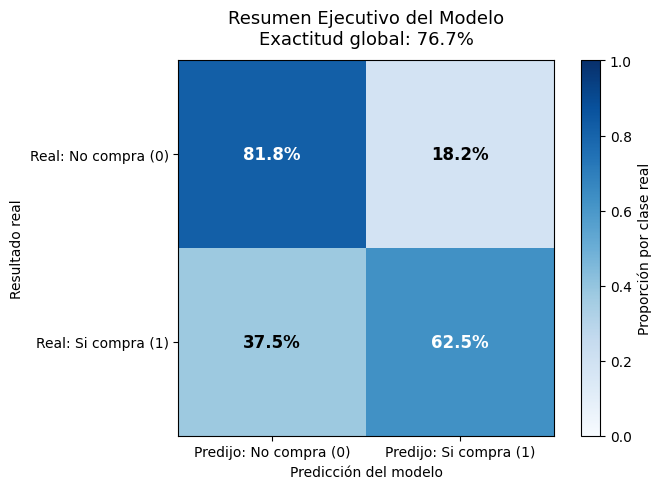

In [25]:
# Matriz de confusión en porcentaje (enfoque ejecutivo)
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predicciones, labels=[0, 1], normalize='true')

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)

# Etiquetas claras para audiencia no técnica
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predijo: No compra (0)', 'Predijo: Si compra (1)'])
ax.set_yticklabels(['Real: No compra (0)', 'Real: Si compra (1)'])

# Escribimos porcentajes dentro de cada celda
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        valor = cm[i, j]
        color = 'white' if valor > 0.5 else 'black'
        ax.text(j, i, f'{valor:.1%}', ha='center', va='center', color=color, fontsize=12, fontweight='bold')

accuracy = accuracy_score(y_test, predicciones)
ax.set_title(f'Resumen Ejecutivo del Modelo\nExactitud global: {accuracy:.1%}', fontsize=13, pad=12)
ax.set_xlabel('Predicción del modelo')
ax.set_ylabel('Resultado real')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Proporción por clase real')

plt.tight_layout()
plt.show()

## Cómo interpretar este gráfico (explicación ejecutiva)

Este gráfico muestra, en porcentaje, qué tan bien el modelo distingue entre clientes que **compran** y **no compran** seguro.

### 1) Qué representan los ejes
- Eje vertical (filas): resultado **real**.
- Eje horizontal (columnas): resultado **predicho** por el modelo.

### 2) Qué significa cada cuadrante
- **Arriba izquierda**: clientes que no compran y el modelo clasificó correctamente.
- **Abajo derecha**: clientes que sí compran y el modelo clasificó correctamente.
- **Arriba derecha**: clientes que no compran, pero el modelo dijo que sí compran (falso positivo).
- **Abajo izquierda**: clientes que sí compran, pero el modelo dijo que no compran (falso negativo).

### 3) Regla rápida para gerencia
- Mientras más altos sean los porcentajes de la **diagonal principal** (arriba izquierda y abajo derecha), mejor está funcionando el modelo.
- Los valores fuera de la diagonal son errores y deben mantenerse bajos.

### 4) Qué decisión de negocio apoya
Este gráfico ayuda a decidir si el modelo es suficientemente confiable para apoyar campañas comerciales, porque muestra claramente:
- Qué porcentaje de clientes correctos detecta.
- Qué tipo de error comete con mayor frecuencia.
- Dónde conviene ajustar la estrategia comercial (contactar más, filtrar mejor o cambiar el umbral de decisión).


# Qué significa cada parte:

- y_test
> Son las respuestas reales (la verdad).

- predicciones
> Son las respuestas que dio el modelo.

- classification_report(...)
Compara reales vs predichas y entrega métricas por clase (por ejemplo clase 0 y clase 1).

- digits=3
Muestra los resultados con 3 decimales (ejemplo: 0.667).

- zero_division=0 significa:

    - Si una métrica necesita dividir por cero, sklearn no lanza error ni warning.
    - En ese caso, asigna el valor 0.0 a esa métrica.

# Qué muestra el reporte:

- precision
De todo lo que el modelo predijo como una clase, qué porcentaje era correcto.

- recall
De todos los casos reales de esa clase, cuántos detectó el modelo.

- f1-score
Promedio balanceado entre precision y recall.

- support
Cuántos ejemplos reales hay de esa clase en y_test.

También aparecen filas resumen:

- accuracy
Exactitud global del modelo.

- macro avg
Promedio simple entre clases (trata todas las clases por igual).

- weighted avg
Promedio ponderado por la cantidad de ejemplos de cada clase.

**En simple: esa función te dice no solo cuánto acierta en general, sino también cómo se comporta en cada clase**

In [24]:


# 6) Predicción de un caso nuevo
nuevo_cliente = pd.DataFrame({
    'edad': [25],
    'ingreso_mensual': [700000],
    'region': ['Metropolitana'],
    'nivel_alerta': ['media']
})

pred_nuevo = pipeline_clase.predict(nuevo_cliente)[0] # Predice si el nuevo cliente compraría el seguro (0 o 1)
prob_nuevo = pipeline_clase.predict_proba(nuevo_cliente)[0, 1] 
# Obtiene la probabilidad estimada de que el nuevo cliente compre el seguro 
# (columna 1 del resultado de predict_proba)

print('\nPredicción nuevo cliente (compra_seguro):', int(pred_nuevo))
print('Probabilidad estimada de compra:', round(prob_nuevo, 3))


Predicción nuevo cliente (compra_seguro): 0
Probabilidad estimada de compra: 0.015


# Tabla orientativa de calidad de precisión (clasificación):

> Rango de precisión	Porcentaje	Nivel	Interpretación
- 0,90 a 1,00	90% a 100%	Óptimo	Muy buen desempeño, errores bajos
- 0,80 a 0,89	80% a 89%	Bueno	Buen desempeño en la mayoría de escenarios
- 0,70 a 0,79	70% a 79%	Aceptable	Útil, pero todavía mejorable
- 0,60 a 0,69	60% a 69%	Pesimista	Rendimiento débil, revisar variables/modelo
- 0,00 a 0,59	0% a 59%	Malo	Desempeño insuficiente para producción

In [ ]:
# 7) Exportar a CSV los datos transformados del DataFrame
# Usamos el preprocesamiento ya ajustado en el pipeline para transformar todo X
X_transformado = pipeline_clase.named_steps['preprocesamiento'].transform(X)

# Obtenemos nombres de columnas transformadas
nombres_columnas = pipeline_clase.named_steps['preprocesamiento'].get_feature_names_out()

# Si la salida es sparse, la convertimos a densa para crear el DataFrame
if hasattr(X_transformado, 'toarray'):
    X_transformado = X_transformado.toarray()

df_transformado = pd.DataFrame(X_transformado, columns=nombres_columnas)
df_transformado['compra_seguro'] = y.reset_index(drop=True)

archivo_salida = 'dataset_chile_200_transformado.csv'
df_transformado.to_csv(archivo_salida, index=False, encoding='utf-8-sig')

print(f'Archivo generado: {archivo_salida}')
print('Dimensiones del dataset transformado:', df_transformado.shape)
display(df_transformado.head())